<a href="https://colab.research.google.com/github/gaga0321/scRNA-aging-analysis/blob/main/scRNA_aging_analysis_BAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install scanpy
import scanpy as sc
adata_aging = sc.read_h5ad("tabula-muris-senis-facs-processed-official-annotations-BAT.h5ad")
print(list(adata_aging.obs.columns))

['FACS.selection', 'age', 'cell', 'cell_ontology_class', 'cell_ontology_id', 'free_annotation', 'method', 'mouse.id', 'sex', 'subtissue', 'tissue', 'n_genes', 'n_counts', 'louvain', 'leiden']


/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


Ages in this cohort: ['18m', '24m', '3m']

Top 5 cell types found in this tissue:
cell_ontology_class
myeloid cell                        760
B cell                              529
endothelial cell                    413
mesenchymal stem cell of adipose    205
T cell                              155
Name: count, dtype: int64


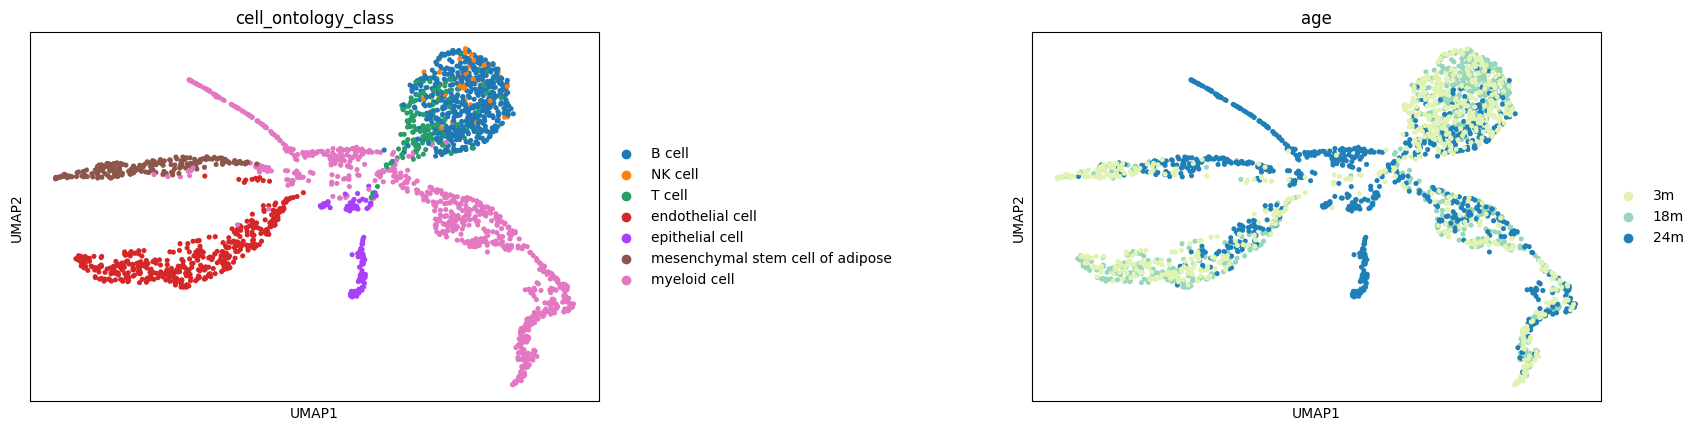

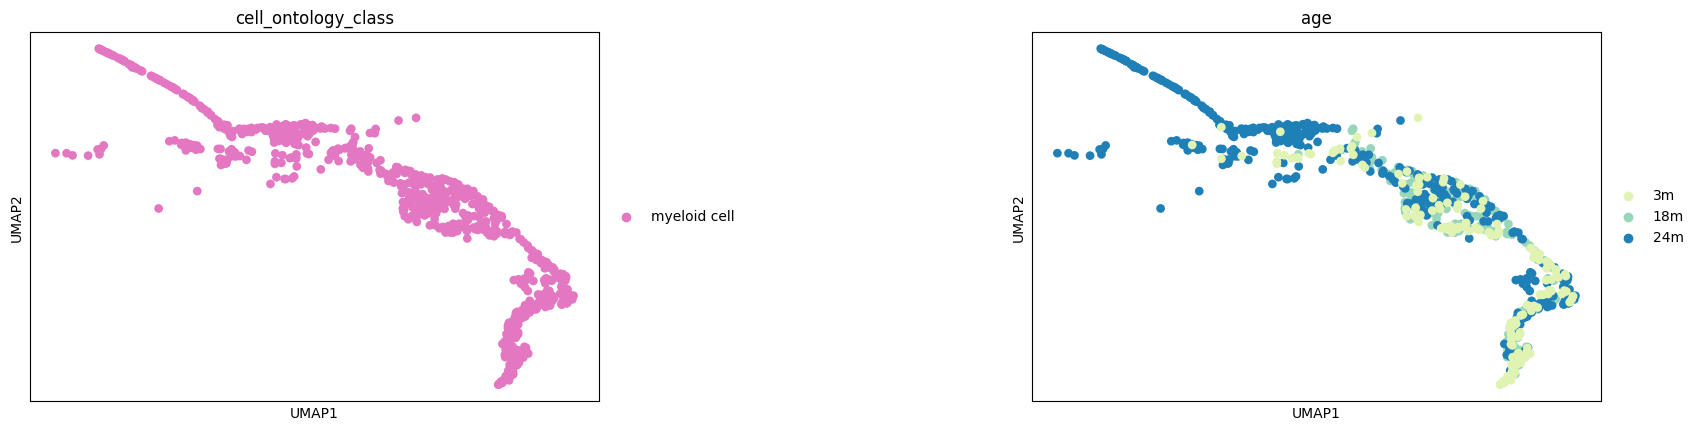

In [12]:
print("Ages in this cohort:", adata_aging.obs['age'].unique().tolist())
print("\nTop 5 cell types found in this tissue:")
print(adata_aging.obs['cell_ontology_class'].value_counts().head(5))
sc.pl.umap(adata_aging, color=['cell_ontology_class', 'age'], wspace=0.6)
myeloid_cells = adata_aging[adata_aging.obs['cell_ontology_class'] == 'myeloid cell'].copy()
sc.pl.umap(myeloid_cells, color=['cell_ontology_class', 'age'], wspace=0.6)

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (


Top Aging Myeloid Cell Genes (p < 0.05):
               18m_n     18m_l     18m_p
230            Wdr89  6.347329  0.000008
22955        Tmem119  7.941234  0.000114
307          Gm12657  4.067704  0.000325
22952         Olfml3  1.463447  0.000387
330          Fam100b  8.557492  0.000742
366           Gm5148  8.568589  0.001774
371         Mir684-1  4.107185  0.001962
375         Mir692-1  0.766132  0.002142
376           Gm6682  5.592788  0.002183
405            Spry2  6.686068  0.004026
410        Hist1h2ao  5.039602  0.004535
22943         Ccdc80  9.366391  0.011862
475       Rps15a-ps6  4.502934  0.014420
22941          Gpr34  3.528570  0.016489
539    A730098P11Rik  4.904611  0.035161


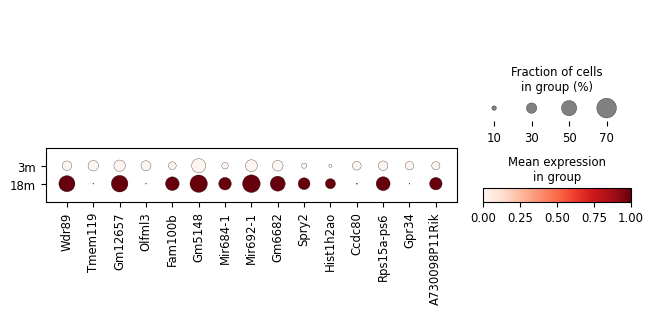

Top Downregulated Myeloid Cell Genes (p < 0.05):
          18m_n      18m_l         18m_p
22964     Sparc -13.259843  4.728033e-18
22959      Plp1  -2.163894  1.369270e-06
22951  Serping1  -3.448840  2.796357e-03
22950       Dpt  -0.276620  6.031894e-03
22949       Lum  -7.383675  6.271441e-03
22938   Sparcl1  -6.791619  4.457501e-02


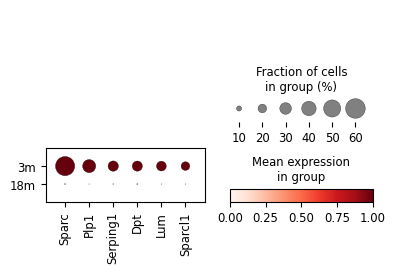

In [36]:
import pandas as pd
sc.pp.normalize_total(myeloid_cells, target_sum=1e4)
sc.pp.log1p(myeloid_cells)
sc.tl.rank_genes_groups(
    myeloid_cells,
    groupby='age',
    groups=['18m'],
    reference='3m',
    method='wilcoxon'
)
result = myeloid_cells.uns['rank_genes_groups']
groups = result['names'].dtype.names
dataframe = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj']}
)

upregulated_genes = dataframe[
    (dataframe['18m_l'] > 0) &
    (dataframe['18m_l'] < 15) &
    (dataframe['18m_l'] != float('inf'))
]
final_up_df = upregulated_genes[upregulated_genes['18m_p'] < 0.05].sort_values(by='18m_p', ascending=True)
print("Top Aging Myeloid Cell Genes (p < 0.05):")
print(final_up_df[['18m_n', '18m_l', '18m_p']].head(20))
top_genes = final_up_df['18m_n'].head(20).tolist()
subset_myeloid = myeloid_cells[myeloid_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset_myeloid,
    var_names=top_genes,
    groupby='age',
    standard_scale='var'
)

downregulated_genes = dataframe[
    (dataframe['18m_l'] < 0) &             # Must be actively turned OFF in 18m cells
    (dataframe['18m_l'] > -15) &           # Blocks the negative ambient noise floor
    (dataframe['18m_l'] != float('-inf'))  # Blocks literal negative infinity
]
final_down_df = downregulated_genes[downregulated_genes['18m_p'] < 0.05].sort_values(by='18m_p', ascending=True)
print("Top Downregulated Myeloid Cell Genes (p < 0.05):")
print(final_down_df[['18m_n', '18m_l', '18m_p']].head(20))
top_down_genes = final_down_df['18m_n'].head(20).tolist()
subset_myeloid = myeloid_cells[myeloid_cells.obs['age'].isin(['3m', '18m'])].copy()
sc.pl.dotplot(
    subset_myeloid,
    var_names=top_down_genes,
    groupby='age',
    standard_scale='var'
)